[Previous: Module 1: The Qubit & Superposition](01_The_Qubit_and_Superposition.ipynb)  |  [Course Index](00_Start_Here.ipynb)  |  [Next: Module 3: Multiple Qubits & Entanglement](03_Multiple_Qubits_and_Entanglement.ipynb)

# Module 2: Quantum Logic Gates

**Learning objectives.** After this module you can:

* explain why every gate is a unitary matrix and therefore a *rotation* of the Bloch sphere;
* predict what X, Y, Z and H do to $|0\rangle$ and to $|+\rangle$, and verify it in code;
* use rotation gates (RY, RZ) to prepare any state, and compute the probabilities they produce;
* read a circuit as a sequence of matrix multiplications and predict its result before running it.

**Prerequisites.** [Module 1](01_The_Qubit_and_Superposition.ipynb): amplitudes and the Bloch sphere.

## 1. Gates are rotations (and matrices)

A classical gate like AND takes two bits and returns one; information is thrown away.
Quantum gates are different in two ways:

1. A gate is a **matrix** $U$ acting on the state vector: $|\psi_{\text{out}}\rangle = U|\psi_{\text{in}}\rangle$.
2. The matrix must be **unitary**, $U^\dagger U = I$, so that probabilities still add to one. Unitary matrices never lose information; every gate can be undone by $U^\dagger$.

For one qubit, "unitary" means "a rotation of the Bloch sphere". Every single-qubit gate moves the point around the sphere without stretching anything.

Qiskit's `Operator` class turns any gate, or any whole circuit, into its matrix.

In [1]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator, Statevector
from qiskit.circuit.library import XGate, YGate, ZGate, HGate, SGate, TGate
from qiskit.visualization import array_to_latex

for name, gate in [("X", XGate()), ("Y", YGate()), ("Z", ZGate()), ("H", HGate()), ("S", SGate()), ("T", TGate())]:
    U = Operator(gate).data
    display(array_to_latex(U, prefix=f"{name} = "))

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [2]:
# Unitary means reversible. X twice, or H twice, is the identity:
X = Operator(XGate()).data
H = Operator(HGate()).data

print("X @ X == I ?", np.allclose(X @ X, np.eye(2)))
print("H @ H == I ?", np.allclose(H @ H, np.eye(2)))
print("H is unitary (H† H == I) ?", np.allclose(H.conj().T @ H, np.eye(2)))

X @ X == I ? True
H @ H == I ? True
H is unitary (H† H == I) ? True


## 2. The Pauli gates: X, Y, Z

Each Pauli gate is a **180° rotation** about its axis of the Bloch sphere.

**X (the quantum NOT).** Rotates 180° about the X axis, swapping the poles:

$$X|0\rangle = \begin{pmatrix} 0 & 1 \\ 1 & 0 \end{pmatrix}\begin{pmatrix} 1 \\ 0 \end{pmatrix} = \begin{pmatrix} 0 \\ 1 \end{pmatrix} = |1\rangle.$$

**Y.** Rotates 180° about the Y axis. It also swaps the poles, but with an extra factor of $i$ that matters once phases matter.

**Z (the phase flip).** Rotates 180° about the Z axis. The poles are *on* the Z axis, so $Z|0\rangle = |0\rangle$ and $Z|1\rangle = -|1\rangle$ (a sign, invisible to measurement).
But a state on the equator is moved to the opposite side: $Z|+\rangle = |-\rangle$.

The key lesson: **what a gate does depends on where the state already is.** Let's watch each gate act on $|0\rangle$, then on $|+\rangle$.

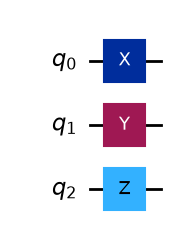

Starting from |0>:   qubit 0 <- X,   qubit 1 <- Y,   qubit 2 <- Z


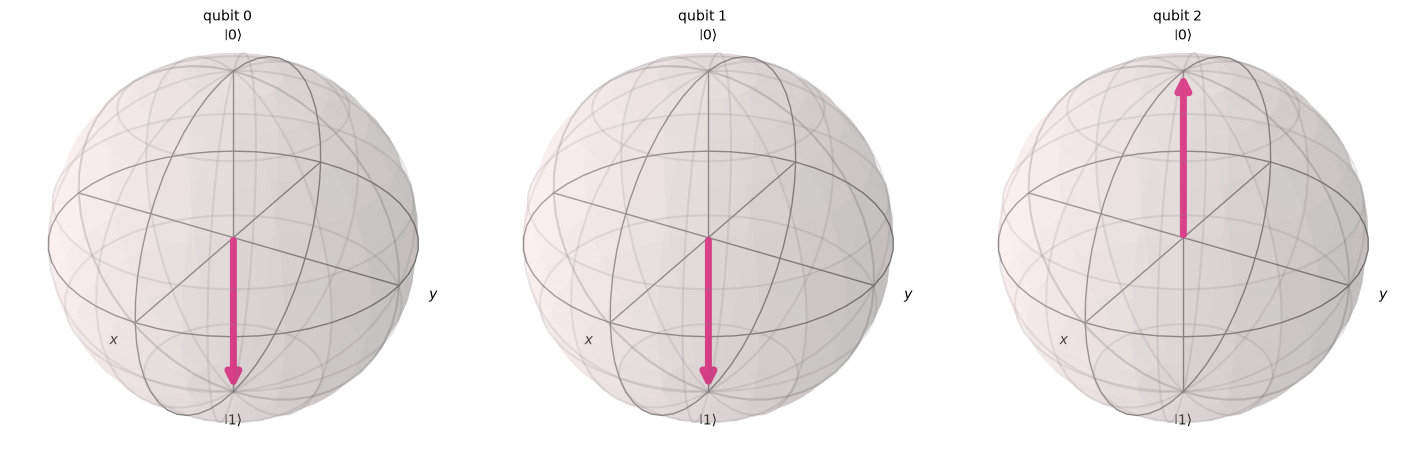

In [3]:
from qiskit.visualization import plot_bloch_multivector

# Three qubits, each starting at |0>. Apply X, Y, Z respectively.
qc = QuantumCircuit(3)
qc.x(0)
qc.y(1)
qc.z(2)
display(qc.draw('mpl'))

print("Starting from |0>:   qubit 0 <- X,   qubit 1 <- Y,   qubit 2 <- Z")
display(plot_bloch_multivector(Statevector(qc)))

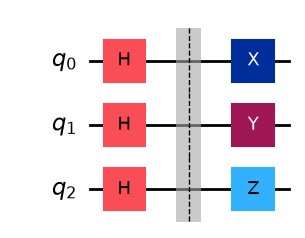

Starting from |+>:   qubit 0 <- X,   qubit 1 <- Y,   qubit 2 <- Z


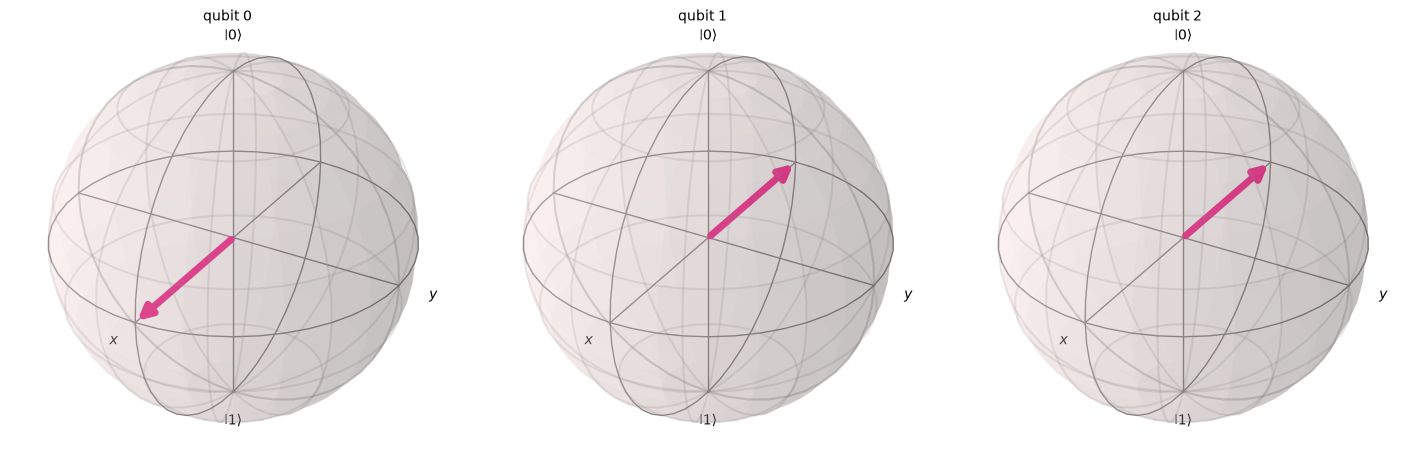

In [4]:
# Same gates, but first move every qubit to |+> with a Hadamard.
qc = QuantumCircuit(3)
qc.h([0, 1, 2])
qc.barrier()           # purely visual separator
qc.x(0)
qc.y(1)
qc.z(2)
display(qc.draw('mpl'))

print("Starting from |+>:   qubit 0 <- X,   qubit 1 <- Y,   qubit 2 <- Z")
display(plot_bloch_multivector(Statevector(qc)))

> **What to notice.** From $|0\rangle$: X and Y both reach the south pole, Z does nothing.
> From $|+\rangle$: X does *nothing* (the state is on the X axis), while Y and Z both flip it to $|-\rangle$.
> A gate is a rotation about an axis, and states on that axis are unmoved.

## 3. The Hadamard gate: the superposition maker

$$H = \frac{1}{\sqrt{2}} \begin{pmatrix} 1 & 1 \\ 1 & -1 \end{pmatrix}, \qquad H|0\rangle = |+\rangle, \qquad H|1\rangle = |-\rangle.$$

Geometrically H is a 180° rotation about the axis half-way between X and Z. It **swaps the X and Z axes**:
the poles go to the equator and the equator goes to the poles. Because it is its own inverse, applying H twice returns the original state.

That last fact is the seed of interference (Module 4): $H|0\rangle$ is a 50/50 superposition, yet $HH|0\rangle$ is exactly $|0\rangle$, never $|1\rangle$.

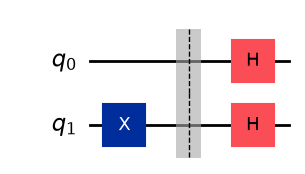

qubit 0: H|0> = |+>       qubit 1: H|1> = |->


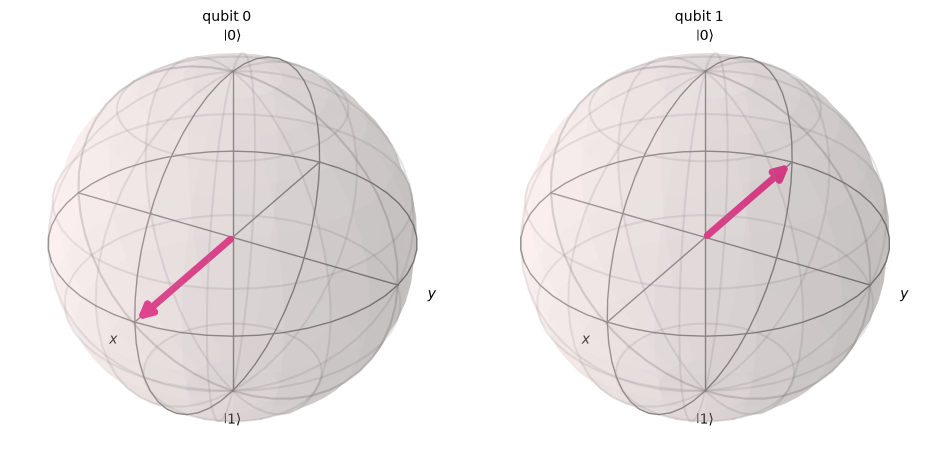

Amplitudes of H|1> (note the minus sign):


<IPython.core.display.Latex object>

In [5]:
qc = QuantumCircuit(2)
qc.x(1)          # qubit 1 starts at |1>
qc.barrier()
qc.h([0, 1])     # H on both
display(qc.draw('mpl'))

state = Statevector(qc)
print("qubit 0: H|0> = |+>       qubit 1: H|1> = |->")
display(plot_bloch_multivector(state))

print("Amplitudes of H|1> (note the minus sign):")
display(Statevector.from_label('1').evolve(HGate()).draw('latex'))

## 4. Continuous rotations: RX, RY, RZ and the phase gates

The Pauli gates only rotate by 180°. The rotation gates take any angle $\theta$:

$$R_y(\theta)|0\rangle = \cos\frac{\theta}{2}|0\rangle + \sin\frac{\theta}{2}|1\rangle \quad\Longrightarrow\quad P(1) = \sin^2\frac{\theta}{2}.$$

$R_y$ moves the state along a meridian, so it controls the **probability**.
$R_z(\phi)$ spins the state around the Z axis, so it controls the **phase** without touching the probability.
S and T are just $R_z$ by 90° and 45°; they get names because they appear constantly in real algorithms.

With $R_y$ and $R_z$ you can reach every point on the sphere, which is why Module 1's $(\theta, \phi)$ formula looks the way it does.

interactive(children=(FloatSlider(value=1.0471975511965976, description='θ', max=3.141592653589793, step=0.05)…

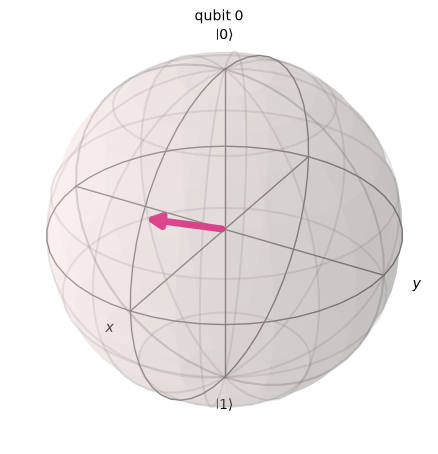

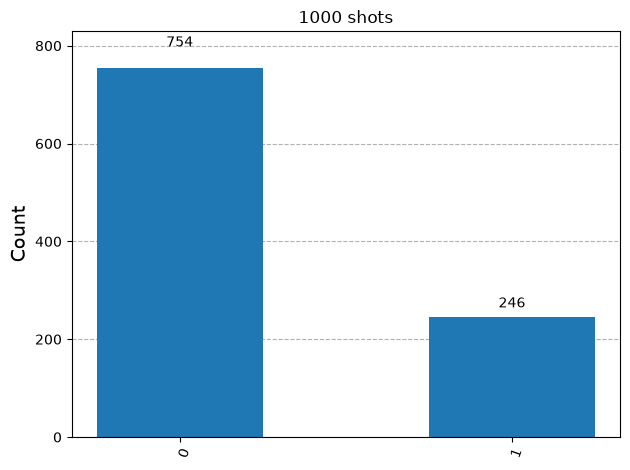

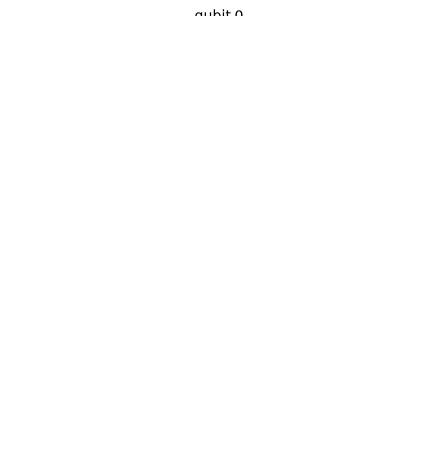

In [6]:
%matplotlib inline
from ipywidgets import interact, FloatSlider
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

simulator = AerSimulator()

def rotate_and_measure(theta):
    qc = QuantumCircuit(1, 1)
    qc.ry(theta, 0)
    state = Statevector(qc)
    qc.measure(0, 0)
    counts = simulator.run(qc, shots=1000).result().get_counts()
    print(f"RY({theta:.2f})|0>    theory P(1) = sin²(θ/2) = {np.sin(theta/2)**2:.3f}"
          f"    measured P(1) = {counts.get('1', 0)/1000:.3f}")
    display(plot_bloch_multivector(state))
    display(plot_histogram(counts, title="1000 shots"))

interact(rotate_and_measure, theta=FloatSlider(min=0, max=np.pi, step=0.05, value=np.pi/3, description='θ'));

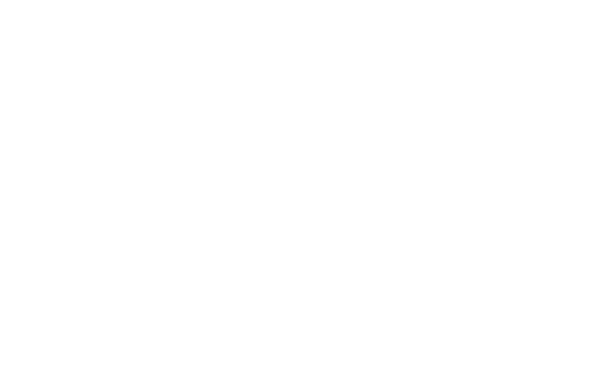

In [7]:
# Sweep the angle and compare the simulator with the formula.
import matplotlib.pyplot as plt

thetas = np.linspace(0, np.pi, 25)
measured = []
for th in thetas:
    qc = QuantumCircuit(1, 1)
    qc.ry(th, 0)
    qc.measure(0, 0)
    counts = simulator.run(qc, shots=500).result().get_counts()
    measured.append(counts.get('1', 0) / 500)

plt.figure(figsize=(7, 4))
plt.plot(thetas, np.sin(thetas/2)**2, label=r'theory: $\sin^2(\theta/2)$')
plt.plot(thetas, measured, 'o', label='simulator, 500 shots each')
plt.xlabel(r'$\theta$ (radians)'); plt.ylabel('P(1)'); plt.title('RY rotation: probability vs angle')
plt.legend(); plt.grid(True); plt.show()

### Lab: reach the target

The lab opens with $|-\rangle$ as a green target arrow. Find three different gate sequences that reach it from $|0\rangle$, using only the buttons.
Then try to reach $|i\rangle$ (the positive Y axis). The fidelity readout tells you when you are there.

In [8]:
from qclab import bloch_lab

bloch_lab(target='-')

## 5. Circuits are matrix products: predict before you run

Reading a circuit left to right, gate $A$ then gate $B$ then gate $C$, the total operation is the matrix product $C\,B\,A$
(right-most acts first). `Operator(circuit)` computes it for you.

Consider this sequence on $|0\rangle$: **X, then H, then Z, then H**. Before running it, guess the measurement result.
Most people guess "random". Let's see.

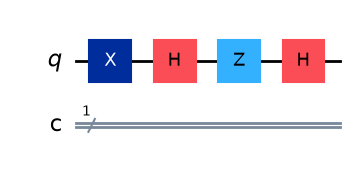

<IPython.core.display.Latex object>

Measured: {'0': 1000}


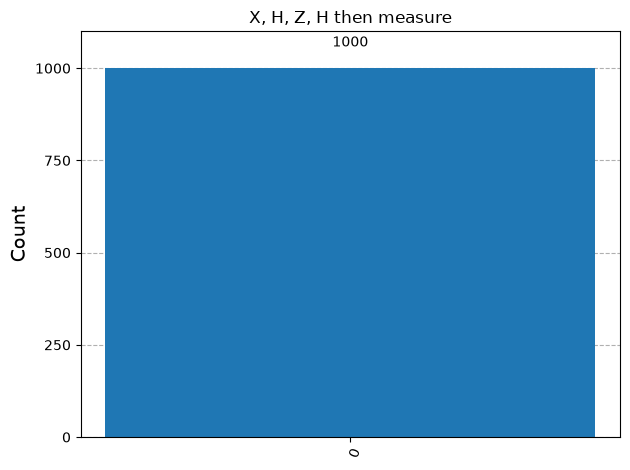

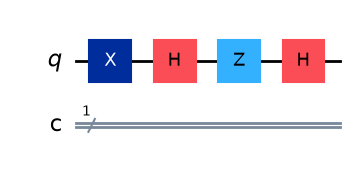

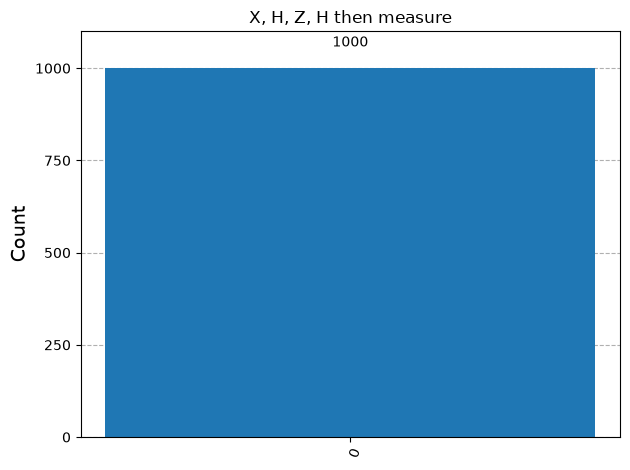

In [9]:
qc = QuantumCircuit(1, 1)
qc.x(0)   # |0> -> |1>
qc.h(0)   # |1> -> |->
qc.z(0)   # |-> -> |+>
qc.h(0)   # |+> -> |0>
display(qc.draw('mpl'))

# The matrix of the whole sequence:
U = Operator(qc.remove_final_measurements(inplace=False))
display(array_to_latex(U.data, prefix=r"H\,Z\,H\,X = "))

qc.measure(0, 0)
counts = simulator.run(qc, shots=1000).result().get_counts()
print("Measured:", counts)
plot_histogram(counts, title="X, H, Z, H then measure")

> **What to notice.** The matrix is the identity: four gates that do nothing overall, and the result is $0$ every time.
> Algebraically $HZH = X$, so the circuit is $X\cdot X = I$. Each gate on its own creates randomness;
> the *sequence* is perfectly deterministic. Quantum programs are about choreography, not individual gates.

### Lab: Circuit Composer

The composer starts with the X, H, Z, H circuit loaded. Look at the amplitude bars after each Undo: press Undo four times and Add the gates back one at a time,
watching the amplitude of $|1\rangle$ appear and vanish. Then switch to 2 qubits and build a circuit of your own.

In [10]:
from qclab import circuit_composer

circuit_composer(1, example='x-h-z-h')

## Gate cheat sheet

| Gate | Qiskit | Matrix | Rotation |
|------|--------|--------|----------|
| X | `qc.x(q)` | $\begin{pmatrix}0&1\\1&0\end{pmatrix}$ | 180° about X |
| Y | `qc.y(q)` | $\begin{pmatrix}0&-i\\i&0\end{pmatrix}$ | 180° about Y |
| Z | `qc.z(q)` | $\begin{pmatrix}1&0\\0&-1\end{pmatrix}$ | 180° about Z |
| H | `qc.h(q)` | $\tfrac{1}{\sqrt2}\begin{pmatrix}1&1\\1&-1\end{pmatrix}$ | 180° about X+Z |
| S | `qc.s(q)` | $\begin{pmatrix}1&0\\0&i\end{pmatrix}$ | 90° about Z |
| T | `qc.t(q)` | $\begin{pmatrix}1&0\\0&e^{i\pi/4}\end{pmatrix}$ | 45° about Z |
| RX($\theta$) | `qc.rx(θ,q)` | $\begin{pmatrix}\cos\frac\theta2&-i\sin\frac\theta2\\-i\sin\frac\theta2&\cos\frac\theta2\end{pmatrix}$ | $\theta$ about X |
| RY($\theta$) | `qc.ry(θ,q)` | $\begin{pmatrix}\cos\frac\theta2&-\sin\frac\theta2\\\sin\frac\theta2&\cos\frac\theta2\end{pmatrix}$ | $\theta$ about Y |
| RZ($\phi$) | `qc.rz(φ,q)` | $\begin{pmatrix}e^{-i\phi/2}&0\\0&e^{i\phi/2}\end{pmatrix}$ | $\phi$ about Z |

Useful identities: $HXH = Z$, $HZH = X$, $S^2 = Z$, $T^2 = S$, $X^2 = Y^2 = Z^2 = H^2 = I$.

## Try it yourself

**Exercise 1.** Prepare $|-\rangle$ from $|0\rangle$ in two different ways. Check both with `plot_bloch_multivector`.

**Exercise 2.** Verify the identity $HXH = Z$ using `Operator` and `np.allclose`.

**Exercise 3.** Which angle $\theta$ makes `ry(θ)` produce a 25 % chance of measuring $1$? Confirm with 1000 shots.

**Exercise 4 (challenge).** The sequence H, S, H on $|0\rangle$ gives what probabilities? Predict, then compute with `Statevector`.

<details><summary>Solutions</summary>

```python
# Exercise 1: H then Z, or X then H
a = QuantumCircuit(1); a.h(0); a.z(0)
b = QuantumCircuit(1); b.x(0); b.h(0)
print(Statevector(a).equiv(Statevector(b)))   # True (equal up to global phase)

# Exercise 2
H, X, Z = (Operator(g).data for g in (HGate(), XGate(), ZGate()))
print(np.allclose(H @ X @ H, Z))              # True

# Exercise 3: sin²(θ/2) = 0.25  ->  θ = 2 asin(0.5) = π/3
theta = 2 * np.arcsin(np.sqrt(0.25))
qc = QuantumCircuit(1, 1); qc.ry(theta, 0); qc.measure(0, 0)
print(AerSimulator().run(qc, shots=1000).result().get_counts())

# Exercise 4: S is a 90° phase; H S H rotates |0> onto the equator-ish -> 50/50
qc = QuantumCircuit(1); qc.h(0); qc.s(0); qc.h(0)
print(Statevector(qc).probabilities_dict())   # {'0': 0.5, '1': 0.5}
```

</details>

## Checkpoint quiz

Four quick questions. Answer them before reading the takeaways. If you miss one, the explanation points you to the section to re-read.

In [11]:
from qclab import quiz

quiz(2)

## Key takeaways

* A gate is a unitary matrix, so it is reversible and, for one qubit, a rotation of the Bloch sphere.
* X, Y, Z are 180° rotations about their axes; H swaps the X and Z axes and creates superposition.
* RY sets probabilities, RZ sets phase; together they reach every state.
* A circuit is a matrix product. Sequences of "random" gates can be perfectly deterministic. `Operator(qc)` lets you check.

**Next:** two qubits, tensor products and the gate that creates entanglement. [Module 3](03_Multiple_Qubits_and_Entanglement.ipynb).

[Previous: Module 1: The Qubit & Superposition](01_The_Qubit_and_Superposition.ipynb)  |  [Course Index](00_Start_Here.ipynb)  |  [Next: Module 3: Multiple Qubits & Entanglement](03_Multiple_Qubits_and_Entanglement.ipynb)